<font size = 6> Обнаружение аномальных данных

Тарасевич Анастасия МММ-601-О-03

# Введение

Цель работы: обнаружение аномальных данных в одномерной выборке, взятой из
ассиметрично распределенной генеральной совокупности.

Подключение пакетов:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

!pip install scikit-posthocs
import scikit_posthocs as sp

!pip install outlier_utils
import outliers as out

Импорт данных из файла и вывод нескольких строк:

In [ ]:
ds0 = pd.read_excel('AmD.ds_out.xlsx')
ds0.head(10)

,v1,v2,v3,v4,v5,v6,v7,v8,v9,v10,...,v31,v32,v33,v34,v35,v36,v37,v38,v39,v40
0,5.514565,7.282898,6.132870,6.707300,11.198298,10.716988,12.212598,13.744755,8.101409,2.905600,...,16.604867,8.403260,7.231576,13.141501,9.627367,2.950796,18.800604,12.222098,10.852709,10.567411
1,10.305519,7.032829,11.823570,5.407932,6.477785,4.239144,13.165709,15.023023,21.786962,14.060748,...,7.812771,7.750943,7.432143,8.730272,9.137983,4.841036,15.141634,15.595402,10.160142,6.757117
2,5.270427,8.051977,12.496672,14.353263,13.949978,14.388083,3.627460,5.794430,6.935402,3.978898,...,5.975374,3.562820,5.176549,12.981918,5.793973,12.991462,9.151829,15.414337,6.553355,15.232409
3,11.288059,5.440892,12.260367,10.929498,18.289432,12.575862,6.278867,9.952780,4.825266,11.764047,...,8.430660,19.981885,16.856238,15.176538,6.884823,7.296419,9.013079,11.778451,11.002278,20.707802
4,7.221782,10.467684,5.822193,6.964007,9.514702,5.256908,18.703718,14.431205,4.177693,7.954399,...,10.971698,5.213358,11.629033,10.477434,13.460791,3.655477,17.173966,12.048092,5.334065,7.136695
5,8.315295,13.236397,12.032084,6.480672,12.305554,6.695344,8.452069,23.676789,3.439046,11.776194,...,12.090549,3.499102,10.687816,7.089367,9.730589,10.700891,9.591795,8.115501,11.734416,14.951285
6,6.156832,10.766364,14.754327,7.057378,9.084042,5.171837,8.470941,2.201648,17.383253,7.853626,...,11.799236,11.685433,10.490990,9.827198,22.903447,13.193750,6.335675,6.562192,7.107042,28.270827
7,8.279349,11.533888,19.666548,9.809557,9.320185,11.290842,9.277077,9.638965,13.548274,9.293828,...,7.276770,4.258493,10.482166,7.583774,19.170734,4.439534,5.233671,9.793607,4.846975,9.295769
8,16.577979,7.898853,7.671715,6.167103,5.697652,15.185171,13.899339,4.332670,11.743536,3.495115,...,11.744855,19.199491,10.590253,8.730993,12.226239,15.309356,3.617315,9.446109,8.537205,5.829176
9,3.901576,5.105852,12.664882,2.088278,1.728347,13.767418,11.965627,12.675454,7.544990,9.058809,...,9.326038,12.309331,14.691286,9.245349,9.489224,20.289518,9.742895,5.233264,5.088800,10.712271


Создание таблицы, которая содержит один столбец из ds0:

In [ ]:
ds = ds0[['v32']].copy()
ds.columns = ['s32']
ds.head(10)

,s32
0,8.403260
1,7.750943
2,3.562820
3,19.981885
4,5.213358
5,3.499102
6,11.685433
7,4.258493
8,19.199491
9,12.309331


Описательная статистика выборки:

In [ ]:
ds.describe()

,s32
count,1000.000000
mean,10.092854
std,4.593034
min,1.177064
25%,6.699581
50%,9.409634
75%,12.840881
max,28.259815


Минимальный интервал, в котором находятся все элементы выборки:

    [1,177064; 28,259815]
   

Полное описание числовых характеристик:

count — объём выборки;

mean — выборочное среднее, т.е. среднее арифметическое всех элементов выборки; является оценкой математического ожидания генеральной совокупности;

std — выборочное стандартное отклонение, т.е. квадратный корень из выборочной дисперсии; является оценкой среднего квадратического отклонения генеральной совокупности;

min — минимальный элемент выборки;

25% — первый квартиль (Q1), т.е. значение, ниже которого расположено 25 % элементов упорядоченной по возрастанию выборки, а выше которого 75 %; является оценкой 25-го процентиля генеральной совокупности;

50% — медиана (второй квартиль, Q2), т.е. значение, ниже которого расположено 50 % элементов упорядоченной по возрастанию выборки, а выше которого 50 %; является оценкой медианы генеральной совокупности;

75% — третий квартиль (Q3), т.е. значение, ниже которого расположено 75 % элементов упорядоченной по возрастанию выборки, а выше которого 25 %; является оценкой 75-го процентиля генеральной совокупности;

max — максимальный элемент выборки.

# Визуализация данных

## Построение диаграммы рассеяния

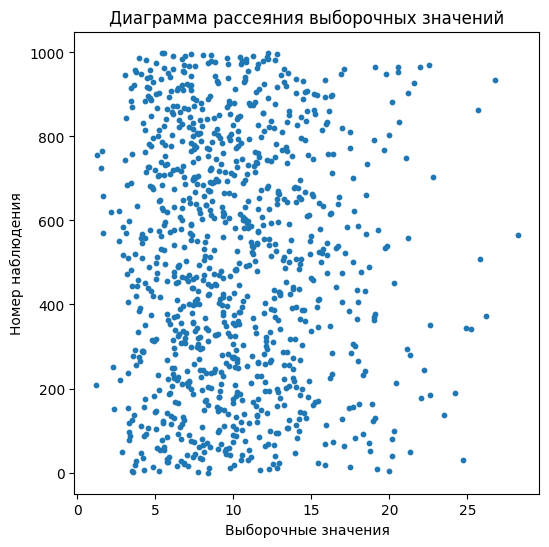

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(ds['s32'], ds.index, s=10)

ax.set_title('Диаграмма рассеяния выборочных значений', fontsize=12)
ax.set_xlabel('Выборочные значения', fontsize=10)
ax.set_ylabel('Номер наблюдения', fontsize=10)

plt.show()

**Анализ диаграммы рассеяния**

В выборке, скорее всего, есть возможные выбросы, которые расположены в правой части диаграммы.

## Построение диаграммы размаха

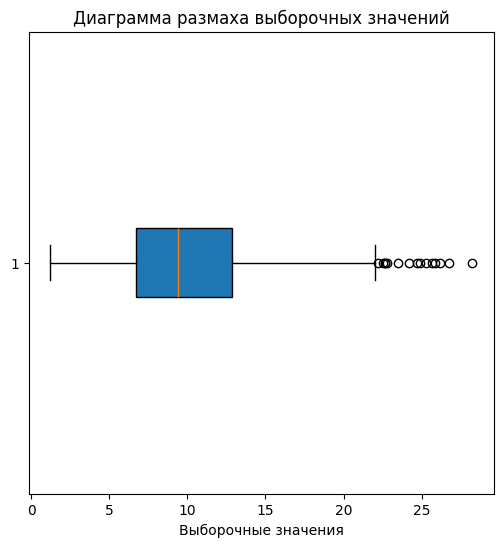

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.boxplot(ds['s32'], vert=False, patch_artist=True)

ax.set_title('Диаграмма размаха выборочных значений', fontsize=12)
ax.set_xlabel('Выборочные значения', fontsize=10)

plt.show()

**Анализ диаграммы размаха**

В выборке, скорее всего, есть возможные выбросы, которые расположены в правой части диаграммы.

**Итоги**

Анализируя диаграммы, можно прийти к выводу, что в выборке, скорее всего, есть возможные выбросы, которые расположены в правой части диаграмм.

# Поиск возможных выбросов

## Поиск выбросов по методу межквартильного размаха (IQR)


In [ ]:
outInd_1 = sp.outliers_iqr(ds['s32'], ret='outliers_indices')
print(outInd_1)

out32_1 = ds.loc[outInd_1]
out32_1

[ 31 136 185 190 244 341 344 350 372 509 565 704 862 935 970]


,s32
31,24.726293
136,23.488366
185,22.626122
190,24.182067
244,22.216330
341,25.256695
344,24.900395
350,22.627979
372,26.207635
509,25.832026


**Вывод**: метод IQR обнаружил 15 наблюдений, которые находятся в правой части распределения (значения больше 22,216), которые являются возможными выбросами.

## Поиск выбросов по методу z-значений

In [ ]:
ds['z_score'] = (ds['s32'] - ds['s32'].mean()) / ds['s32'].std()
ds.head()

out32_2 = ds[abs(ds['z_score']) > 5]
out32_2

,s32,z_score


**Вывод**: при использовании порога |z| > 5 метод z-значений не выявил ни одного возможного выброса.

**Сравнение двух наборов возможных выбросов**

Два метода поиска выбросов дали разные результаты.

Метод IQR обнаружил 15 наблюдений, которые находятся в левой части распределения (значения от 22,216 до 28,260) и являются возможными выбросами.

Метод z-значений с порогом |z| > 5 не обнаружил возможных выбросов. Это говорит о том, что распределение не имеет экстремально далёких значений.

# Преобразование данных

Проверка условия, что все данные положительны:

In [ ]:
ds['s32'].min()

1.177063824119523

Т.к. наименьшее значение выборки равно 1,177063824119523, значит все данные положительны и выполняется необходимое условие для применения преобразования Бокса-Кокса.

Применение преобразования Бокса-Кокса:

In [ ]:
ds['s32_boxcox'], lambda_opt = stats.boxcox(ds['s32'])

ds.head()

,s32,z_score,s32_boxcox
0,8.403260,-0.367860,3.188302
1,7.750943,-0.509883,3.017968
2,3.562820,-1.421726,1.607798
3,19.981885,2.153050,5.359156
4,5.213358,-1.062369,2.249663


Описательная статистика выборки:

Построение диаграммы размаха:

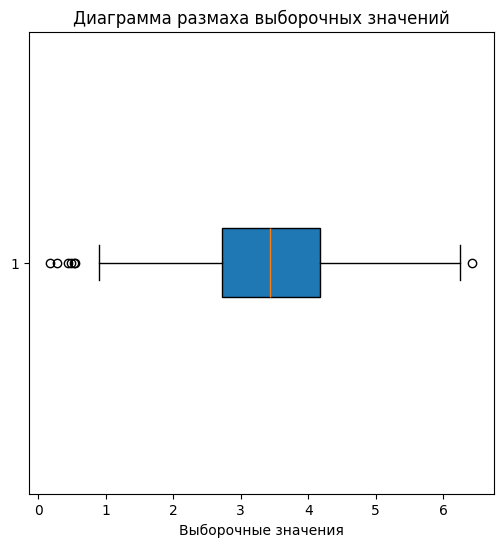

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.boxplot(ds['s32_boxcox'], vert=False, patch_artist=True)

ax.set_title('Диаграмма размаха выборочных значений', fontsize=12)
ax.set_xlabel('Выборочные значения', fontsize=10)

plt.show()

**Анализ диаграммы размаха**

В выборке, скорее всего, присутствуют возможные выбросы.

Таблица со значениями возможных выбросов:

In [ ]:
outInd_3 = sp.outliers_iqr(ds['s32_boxcox'], ret='outliers_indices')
print(outInd_3)

out32_3 = ds.loc[outInd_3]
out32_3

[209 565 569 659 724 755 764]


,s32,z_score,s32_boxcox
209,1.177064,-1.941155,0.167862
565,28.259815,3.955329,6.434252
569,1.632639,-1.841966,0.535718
659,1.620711,-1.844563,0.526994
724,1.510706,-1.868514,0.444519
755,1.293105,-1.915890,0.269213
764,1.553071,-1.859290,0.476724


Метод IQR обнаружил 7 наблюдений, которые являются возможными выбросами.

# Проверка нормальности распределения

## Тест Шапиро-Уилка

In [ ]:
shapiro = stats.shapiro(ds['s32_boxcox'])
print("p-value:", shapiro.pvalue)

p-value: 0.5389111485107054


**Вывод**: так как p-значение (p-value) больше 0,05, то проверяемая гипотеза о нормальности распределения генеральной совокупности, представленной выборкой, не отвергается.

## Тест Андерсона-Дарлинга

In [ ]:
anderson_result = stats.anderson(ds['s32_boxcox'], dist='norm')
print("Наблюдаемое значение:", anderson_result.statistic)
print("Уровень значимости:", anderson_result.significance_level[2])
print("Критическое значение:", anderson_result.critical_values[2])

Наблюдаемое значение: 0.2708072626808189
Уровень значимости: 5.0
Критическое значение: 0.784


**Вывод**: так как при 5%-м уровне значимости наблюдаемое значение меньше критического, то проверяемая гипотеза о нормальности распределения генеральной совокупности, представленной выборкой, не отвергается.

Исходя из результатов двух тестов, при уровне значимости 0,05, проверяемая гипотеза о нормальности распределения генеральной совокупности, представленной выборкой, не отвергается.

# Использование тестов

## Тест Граббса

In [ ]:
max_indices = out.smirnov_grubbs.max_test_indices(ds.s32_boxcox, alpha=0.95)
max_outliers = out.smirnov_grubbs.max_test_outliers(ds.s32_boxcox, alpha=0.95)
print(ds.loc[list(max_indices)])

Empty DataFrame
Columns: [s32, z_score, s32_boxcox]
Index: []


С надёжностью в 95% гипотеза о том, что наибольшее значение выборки не является выбросом, не отвергается.

In [ ]:
min_indices = out.smirnov_grubbs.min_test_indices(ds.s32_boxcox, alpha=0.95)
min_outliers = out.smirnov_grubbs.min_test_outliers(ds.s32_boxcox, alpha=0.95)
print(ds.loc[list(min_indices)])

          s32   z_score  s32_boxcox
209  1.177064 -1.941155    0.167862


С надёжностью в 95% наименьшее значение (индекс которого 209) выборки является выбросом.

Таблица из найденных выбросов и их
индексов в исходной выборке:

In [ ]:
all_grubbs_indices = list(max_indices) + list(min_indices)
ds.loc[all_grubbs_indices]

,s32,z_score,s32_boxcox
209,1.177064,-1.941155,0.167862


Подключение языка R:

In [ ]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


Подсоединение датафрейма к среде R:

In [ ]:
%R -i ds

Установка и подключение библиотеки EnvStats в R:

In [ ]:
%%R
install.packages("EnvStats", repos="https://cloud.r-project.org")
library(EnvStats)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cloud.r-project.org/src/contrib/EnvStats_3.1.0.tar.gz'
Content type 'application/x-gzip' length 1427005 bytes (1.4 MB)
downloaded 1.4 MB


The downloaded source packages are in
	‘/tmp/Rtmp3DcmMp/downloaded_packages’


## Тест Рознера

In [ ]:
%%R
result <- rosnerTest(ds$s32_boxcox, k=7, alpha=0.05)
result$all

  i   Mean.i     SD.i     Value Obs.Num    R.i+1 lambda.i+1 Outlier
1 0 3.438910 1.046953 0.1678616     210 3.124350   4.039978   FALSE
2 1 3.442184 1.042342 0.2692129     756 3.044079   4.039731   FALSE
3 2 3.445364 1.038007 0.4445185     725 2.890968   4.039485   FALSE
4 3 3.448374 1.034162 6.4342518     566 2.887245   4.039237   FALSE
5 4 3.445376 1.030338 0.4767245     765 2.881241   4.038990   FALSE
6 5 3.448359 1.026542 0.5269936     660 2.845831   4.038742   FALSE
7 6 3.451298 1.022862 0.5357183     570 2.850413   4.038494   FALSE


У каждого проверяемого значения наблюдаемая величина (R.i+1) меньше соответствующей критической (lambda.i+1). Поэтому для всех проверяемых значений основная гипотеза о том, что это не выброс, не отвергается.

**Итоги исследования**

Тест Граббса - с надёжностью в 95% объявил наименьшее значение (индекс которого 209) выборки выбросом.

Тест Рознера не отвергает основную гипотезу о том, что все проверяемые значения не являются выбросами.

Было найдено значение, индекс которого 209, которое с надёжностью в 95% является выбросом.

# Заключение

Было проведено обнаружение аномальных данных в одномерной выборке, взятой из
ассиметрично распределенной генеральной совокупности.

В ходе работы была проанализирована выборка объёмом 1000 наблюдений.

**Этапы работы**

1.   **Описательная статистика**. Были найдены числовые характеристики выборки, такие как объём выборки, медиана, выборочное среднее, минимальный элемент выборки, максимальный элемент выборки, первый квартиль, третий квартиль и стандартное отклонение.
2.   **Визуализация данных**. Данные были визуализированы с помощью посроения диаграммы рассеяния и диаграммы размаха. На основании данных диаграмм можно предположить о наличии возможных выбросов в правой части распределения.
3.   **Поиск возможных выбросов.** Были применены метод межквартильного размаха (IQR) — обнаружено 15 наблюдений в правой части распределения; метод z-значений с порогом |z| > 5 — не выявил ни одного выброса.
4.   **Преобразование данных.** К исходным данным было применено преобразование Бокса-Кокса. После преобразования была построена диаграмма размаха, на которой присутствовали точки, выходящие за пределы «усов». Применение метода IQR выявило 7 возможных выбросов.
5. **Проверка нормальности распределения.** Были применены тест Шапиро-Уилка, тест Андерсона-Дарлинга. Оба теста дали результат: проверяемая гипотеза о нормальности распределения генеральной совокупности, представленной выборкой, не отвергается.
6. **Использование тестов на выбросы.** Тест Граббса с надёжностью 95% объявил минимальное значение (индекс 209) выбросом. Тест Рознера не выявил выбросов.

**Итоги работы**

Было найдено значение, индекс которого 209, которое с надёжностью в 95% является выбросом.